# Supervised Algorithms Homework

In this homework assignment, you will apply three fundamental machine learning algorithms to famous datasets:

1. **Linear Regression**: Boston Housing Price Prediction
2. **Logistic Regression**: Breast Cancer Classification
3. **Decision Tree**: Titanic Survival Prediction

### Instructions

- Implement **at least** one algorithm
- Complete each section carefully
- Add your code where indicated by `# YOUR CODE HERE`
- Provide comments explaining your approach

In [1]:
# Import required libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


# Machine Learning Libraries
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Specific Algorithms
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Metrics and Datasets
from sklearn.datasets import fetch_openml
from sklearn.datasets import load_breast_cancer
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report

# Set random seed for reproducibility
np.random.seed(42)

# 1: Linear Regression - Boston Housing Price Prediction

### Task
- Load the Boston Housing dataset
- Preprocess the data
- Split into training and testing sets
- Train a Linear Regression model
- Evaluate model performance

In [2]:
# Load Boston Housing dataset
boston = fetch_openml(name="boston", version=1, as_frame=True)

# Extract features and target
X, y = boston.data, boston.target

/Users/kristinakhvatova/anaconda3/lib/python3.11/site-packages/sklearn/datasets/_openml.py:968: FutureWarning: The default value of `parser` will change from `'liac-arff'` to `'auto'` in 1.4. You can set `parser='auto'` to silence this warning. Therefore, an `ImportError` will be raised from 1.4 if the dataset is dense and pandas is not installed. Note that the pandas parser may return different data types. See the Notes Section in fetch_openml's API doc for details.
  warn(


In [3]:
X.head()

,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296.0,15.3,396.90,4.98
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242.0,17.8,396.90,9.14
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242.0,17.8,392.83,4.03
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222.0,18.7,394.63,2.94
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222.0,18.7,396.90,5.33


In [4]:
X.describe()

,CRIM,ZN,INDUS,NOX,RM,AGE,DIS,TAX,PTRATIO,B,LSTAT
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.554695,6.284634,68.574901,3.795043,408.237154,18.455534,356.674032,12.653063
std,8.601545,23.322453,6.860353,0.115878,0.702617,28.148861,2.105710,168.537116,2.164946,91.294864,7.141062
min,0.006320,0.000000,0.460000,0.385000,3.561000,2.900000,1.129600,187.000000,12.600000,0.320000,1.730000
25%,0.082045,0.000000,5.190000,0.449000,5.885500,45.025000,2.100175,279.000000,17.400000,375.377500,6.950000
50%,0.256510,0.000000,9.690000,0.538000,6.208500,77.500000,3.207450,330.000000,19.050000,391.440000,11.360000
75%,3.677083,12.500000,18.100000,0.624000,6.623500,94.075000,5.188425,666.000000,20.200000,396.225000,16.955000
max,88.976200,100.000000,27.740000,0.871000,8.780000,100.000000,12.126500,711.000000,22.000000,396.900000,37.970000


In [5]:
print(X.isna().sum())

CRIM       0
ZN         0
INDUS      0
CHAS       0
NOX        0
RM         0
AGE        0
DIS        0
RAD        0
TAX        0
PTRATIO    0
B          0
LSTAT      0
dtype: int64


In [6]:
y.head()

0    24.0
1    21.6
2    34.7
3    33.4
4    36.2
Name: MEDV, dtype: float64

In [7]:
# TODO: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [8]:
# TODO: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
# TODO: Train a Linear Regression model
lr_model = LinearRegression()
lr_model.fit(X_train_scaled, y_train)

LinearRegression()

In [11]:
# TODO: Make predictions and calculate performance metrics
y_pred = lr_model.predict(X_test_scaled)
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [12]:
# TODO: Print performance metrics
print(f"Mean Squared Error: {mse:.2f}")
print(f"R squared Error: {r2:.2f} ")

Mean Squared Error: 24.29
R squared Error: 0.67 


In [13]:
# Apply PCA (Principal Component Analysis) algorithm 
### PCA (Principal Component Analysis) is a dimensionality reduction technique used to transform 
### high-dimensional data into fewer dimensions while retaining as much variance as possible.
from sklearn.decomposition import PCA

pca = PCA(n_components=1)  # Reduce to 1 dimensions
principal_components = pca.fit_transform(X_train_scaled)

X_test_1_component = pca.transform(X_test_scaled)

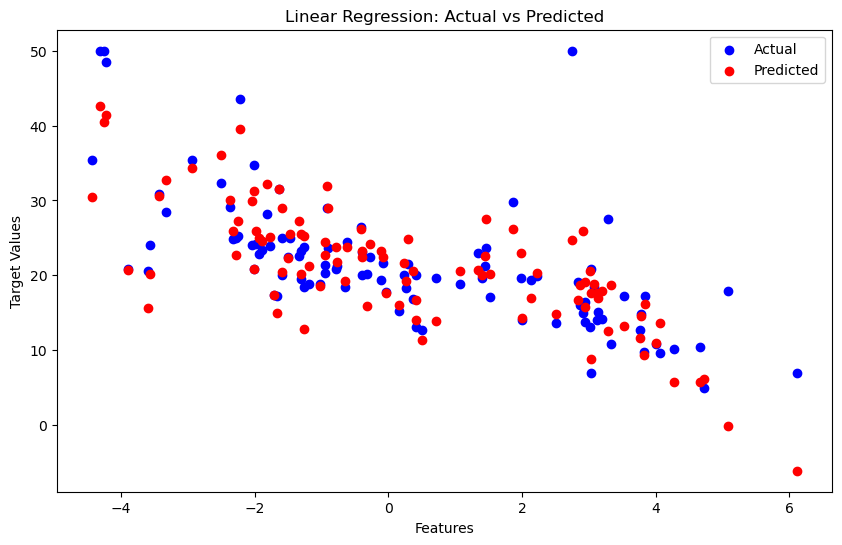

In [14]:
# Visualization
plt.figure(figsize=(10, 6))
plt.scatter(X_test_1_component, y_test, color='blue', label='Actual')
plt.scatter(X_test_1_component, y_pred, color='red', label='Predicted')
plt.title('Linear Regression: Actual vs Predicted')
plt.xlabel('Features')
plt.ylabel('Target Values')
plt.legend()
plt.show()

## Part 2: Logistic Regression - Breast Cancer Classification

### Task
- Load the Breast Cancer dataset
- Preprocess the data
- Split into training and testing sets
- Train a Logistic Regression model
- Evaluate model performance

In [15]:
breast_cancer = load_breast_cancer()
X_cancer = pd.DataFrame(breast_cancer.data, columns=breast_cancer.feature_names)
y_cancer = breast_cancer.target

In [16]:
X_cancer.head()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


In [17]:
X_cancer.describe()

,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
count,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000
mean,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,0.062798,...,16.269190,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946
std,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,0.007060,...,4.833242,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061
min,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,0.049960,...,7.930000,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040
25%,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,0.057700,...,13.010000,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460
50%,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,0.061540,...,14.970000,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040
75%,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,0.066120,...,18.790000,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080
max,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,0.097440,...,36.040000,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500


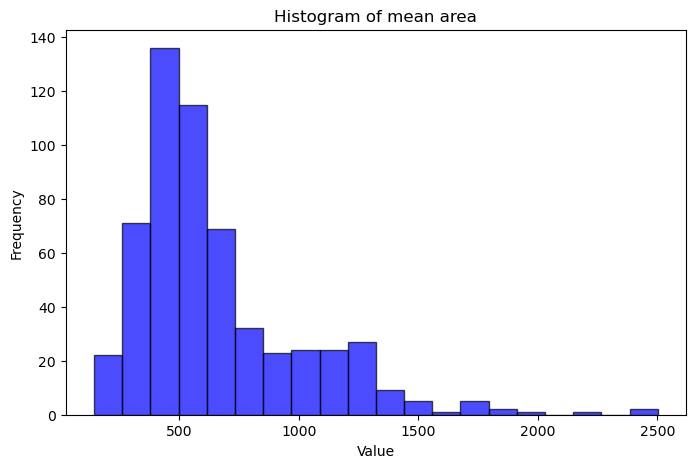

In [18]:
# Histogram
plt.figure(figsize=(8, 5))
plt.hist(X_cancer['mean area'], bins=20, color='blue', edgecolor='black', alpha=0.7)
plt.xlabel('Value')
plt.ylabel('Frequency')
plt.title('Histogram of mean area')
plt.show()

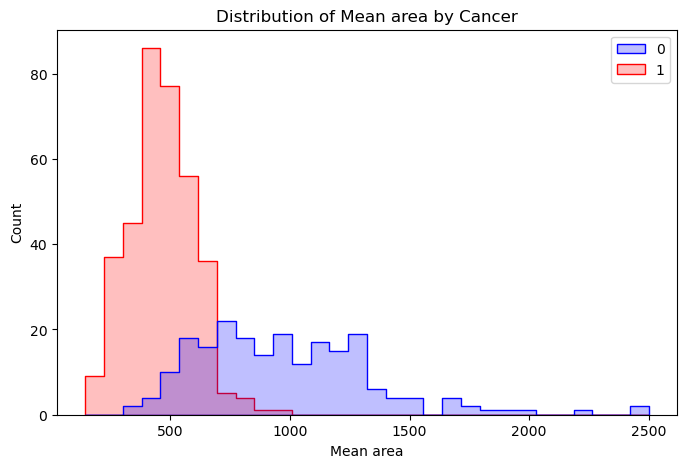

In [19]:
import seaborn as sns

# Plot histogram with hue
plt.figure(figsize=(8, 5))
sns.histplot(x=X_cancer['mean area'], hue=y_cancer, bins=30, kde=False, element="step", palette=['blue', 'red'])
plt.xlabel('Mean area')
plt.ylabel('Count')
plt.title('Distribution of Mean area by Cancer')
plt.show()

In [20]:
print(X_cancer.isna().sum())

mean radius                0
mean texture               0
mean perimeter             0
mean area                  0
mean smoothness            0
mean compactness           0
mean concavity             0
mean concave points        0
mean symmetry              0
mean fractal dimension     0
radius error               0
texture error              0
perimeter error            0
area error                 0
smoothness error           0
compactness error          0
concavity error            0
concave points error       0
symmetry error             0
fractal dimension error    0
worst radius               0
worst texture              0
worst perimeter            0
worst area                 0
worst smoothness           0
worst compactness          0
worst concavity            0
worst concave points       0
worst symmetry             0
worst fractal dimension    0
dtype: int64


In [21]:
y_cancer[:20]

array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1])

In [22]:
np.unique(y_cancer, return_counts=True)

(array([0, 1]), array([212, 357]))

In [23]:
# TODO: Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_cancer, y_cancer, test_size=0.2, random_state=42)

In [24]:
# TODO: Scale the features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [25]:
# TODO: Train a Logistic Regression model
log_model = LogisticRegression(random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(random_state=42)

In [26]:
# TODO: Make predictions and calculate performance metrics
y_pred = log_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test,  y_pred)

In [27]:
# TODO: Print performance metrics
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.97
Classification Report:
              precision    recall  f1-score   support

           0       0.98      0.95      0.96        43
           1       0.97      0.99      0.98        71

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



## Part 3: Decision Tree - Titanic Survival Prediction

### Task
- Load the Titanic dataset
- Preprocess the data (handling missing values, encoding categorical variables)
- Split into training and testing sets
- Train a Decision Tree Classifier
- Evaluate model performance

In [28]:
# Load Titanic dataset
titanic = pd.read_csv('https://web.stanford.edu/class/archive/cs/cs109/cs109.1166/stuff/titanic.csv')

In [29]:
# Data Preprocessing
titanic.head()

,Survived,Pclass,Name,Sex,Age,Siblings/Spouses Aboard,Parents/Children Aboard,Fare
0,0,3,Mr. Owen Harris Braund,male,22.0,1,0,7.2500
1,1,1,Mrs. John Bradley (Florence Briggs Thayer) Cum...,female,38.0,1,0,71.2833
2,1,3,Miss. Laina Heikkinen,female,26.0,0,0,7.9250
3,1,1,Mrs. Jacques Heath (Lily May Peel) Futrelle,female,35.0,1,0,53.1000
4,0,3,Mr. William Henry Allen,male,35.0,0,0,8.0500


In [30]:
# Visualize missing values
print(titanic.isnull().sum())

Survived                   0
Pclass                     0
Name                       0
Sex                        0
Age                        0
Siblings/Spouses Aboard    0
Parents/Children Aboard    0
Fare                       0
dtype: int64


In [31]:
# Feature selection
features = ['Pclass', 'Sex', 'Age', 'Fare']
X_titanic = titanic[features]
y_titanic = titanic['Survived']

In [32]:
# TODO: Split the data into training and testing sets
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X_titanic, y_titanic, test_size=0.2, random_state=42)

In [33]:
X_train

,Pclass,Sex,Age,Fare
730,2,male,23.0,13.0000
390,3,male,28.0,7.9250
118,3,female,2.0,31.2750
440,2,female,28.0,13.0000
309,1,female,18.0,262.3750
...,...,...,...,...
106,3,male,29.0,7.7750
270,2,female,41.0,19.5000
860,2,male,24.0,13.0000
435,1,male,64.0,263.0000


In [34]:
# TODO: Scale the features
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

scaler = StandardScaler()
X_train_scaled[['Age', 'Fare']] = scaler.fit_transform(X_train[['Age', 'Fare']])
X_test_scaled[['Age', 'Fare']] = scaler.transform(X_test[['Age', 'Fare']])

In [35]:
X_train_scaled['Sex'] = (X_train_scaled['Sex'] == 'male').astype(int)
X_test_scaled['Sex'] = (X_test_scaled['Sex'] == 'male').astype(int)

In [36]:
X_train_scaled.head()

,Pclass,Sex,Age,Fare
730,2,1,-0.449010,-0.388597
390,3,1,-0.094153,-0.484577
118,3,0,-1.939405,-0.042975
440,2,0,-0.094153,-0.388597
309,1,0,-0.803866,4.327664


In [37]:
# TODO: Train a Decision Tree Classifier
# Train decision tree model
tree_model = DecisionTreeClassifier(max_depth=3, random_state=42)
tree_model.fit(X_train_scaled, y_train)

DecisionTreeClassifier(max_depth=3, random_state=42)

In [38]:
# TODO: Make predictions and calculate performance metrics
# Predict and evaluate
y_pred = tree_model.predict(X_test_scaled)
accuracy = accuracy_score(y_test, y_pred)

print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.78
Classification Report:
              precision    recall  f1-score   support

           0       0.78      0.88      0.83       111
           1       0.75      0.60      0.67        67

    accuracy                           0.78       178
   macro avg       0.77      0.74      0.75       178
weighted avg       0.77      0.78      0.77       178



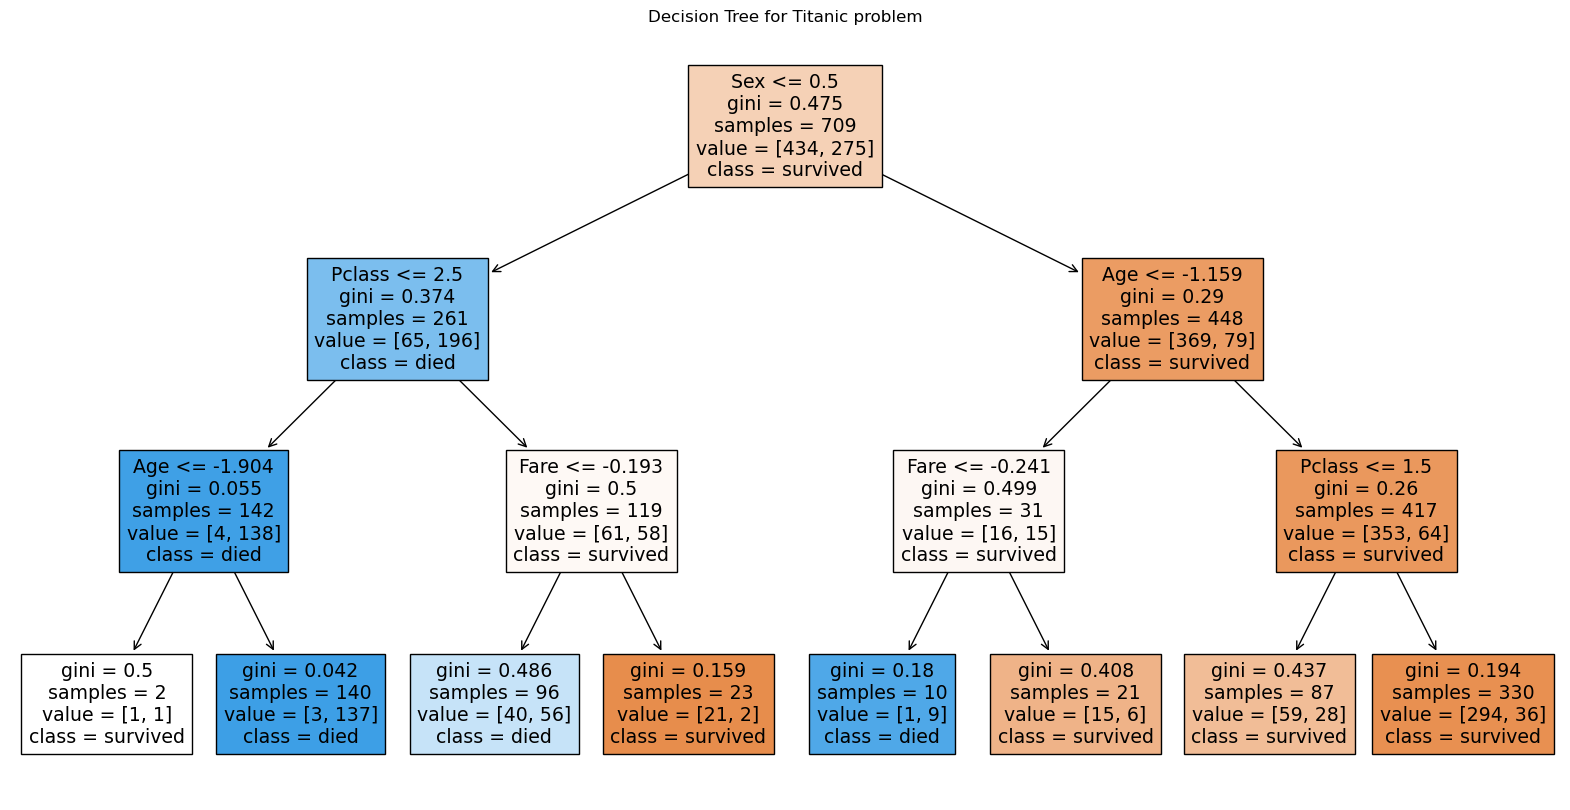

In [39]:
# TODO: Visualize Decisoion Tree
plt.figure(figsize=(20, 10))
plot_tree(tree_model, feature_names=X_titanic.columns, class_names=['survived', 'died'], filled=True)
plt.title('Decision Tree for Titanic problem')
plt.show()

**Tree Depth**: The depth of a decision tree is the number of splits (or decisions) made from the root node (starting point) to the deepest leaf node.

- Root node is level 0.
- First level of children nodes are level 1.
- Second level of children nodes are level 2, and so on.